**Goal** :  We explore data from `annotated_cath_qc0.5_t0.5_l0.5.tsv` and `annotated_cath_qc0.8_t0.5_l0.5.tsv` files.


# I. Installation and Data Loading

In [1]:
# Imports
import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Path to data
cath5_path = "/u/mdmc/enyanduk/internship_areasciencepark/Data/dpcstruct/annotated_cath_qc0.5_t0.5_l0.5.tsv"

In [3]:
with open(cath5_path, "r",encoding="utf-8") as f:
  print(repr(f.readline()))

'query target qstart qend tstart tend qlen tlen qcov tcov alnlen pident evalue bits qtmscore ttmscore alntmscore lddt prob\n'


`Oberservation` : It's a `spaces`-separated file.

In [4]:
# Read in the data
df_cath5 = pd.read_csv(cath5_path, sep=r"\s+")
df_cath5.head()

,query,target,qstart,qend,tstart,tend,qlen,tlen,qcov,tcov,alnlen,pident,evalue,bits,qtmscore,ttmscore,alntmscore,lddt,prob
0,4.10.270,A0A7F8Q518_39405,1,55,127,181,68,182,0.809,0.302,55,61.8,1.218000e-02,88,0.5797,0.2543,0.2543,8.906E-01,0.995
1,2.170.210,A0A7J6I9T2_8385,25,168,35,172,172,180,0.837,0.767,156,12.1,4.788000e-01,37,0.2210,0.2132,0.2132,5.044E-01,0.164
2,3.40.20,A0A416P6C2_7370,7,134,27,155,134,160,0.955,0.806,151,11.9,7.372000e-01,-2147483648,0.1982,0.1710,0.1710,-NAN,0.000
3,3.90.105,A0A126G1X7_6894,2,58,96,160,58,281,0.983,0.231,69,18.8,6.116000e-03,120,0.8315,0.1831,0.1831,8.005E-01,1.000
4,1.20.1740,A0A2J6WLT6_15600,11,417,2,411,435,412,0.936,0.995,427,21.7,3.007000e-15,682,0.8248,0.8685,0.8685,6.804E-01,1.000


In [5]:
# CATH 0.8
cath8_path = "/u/mdmc/enyanduk/internship_areasciencepark/Data/dpcstruct/annotated_cath_qc0.8_t0.5_l0.5.tsv"
with open(cath8_path, "r",encoding="utf-8") as f:
  print(repr(f.readline()))
df_cath8 = pd.read_csv(cath8_path, sep=r"\s+")
df_cath8.head()

'query target qstart qend tstart tend qlen tlen qcov tcov alnlen pident evalue bits qtmscore ttmscore alntmscore lddt prob\n'


,query,target,qstart,qend,tstart,tend,qlen,tlen,qcov,tcov,alnlen,pident,evalue,bits,qtmscore,ttmscore,alntmscore,lddt,prob
0,4.10.270,A0A7F8Q518_39405,1,55,127,181,68,182,0.809,0.302,55,61.8,1.218000e-02,88,0.5797,0.2543,0.2543,8.906E-01,0.995
1,2.170.210,A0A7J6I9T2_8385,25,168,35,172,172,180,0.837,0.767,156,12.1,4.788000e-01,37,0.2210,0.2132,0.2132,5.044E-01,0.164
2,3.40.20,A0A0D8XCM8_6520,9,134,15,153,134,171,0.940,0.813,155,12.2,5.250000e-01,-2147483648,0.2326,0.1950,0.1950,-NAN,0.000
3,3.90.105,A0A126G1X7_6894,2,58,96,160,58,281,0.983,0.231,69,18.8,6.116000e-03,120,0.8315,0.1831,0.1831,8.005E-01,1.000
4,1.20.1740,A0A2J6WLT6_15600,11,417,2,411,435,412,0.936,0.995,427,21.7,3.007000e-15,682,0.8248,0.8685,0.8685,6.804E-01,1.000


In [6]:
# We check whether annotated_cath_qc0.8_t0.5_l0.5.csv is a subset of annotated_cath_qc0.5_t0.5_l0.5.csv
set_cath5 = set(df_cath5["query"])
set_cath8 = set(df_cath8["query"])
print("Is annotated_cath_qc0.8_t0.5_l0.5.csv a subset(sub dataframe) of annotated_cath_qc0.5_t0.5_l0.5?", set_cath8.issubset(set_cath5))

# We check the intersection size
print(f"annotated_cath_qc0.5_t0.5_l0.5 size: {len(set_cath5)}")
print(f"annotated_cath_qc0.8_t0.5_l0.5 size: {len(set_cath8)}")
print(f"Intersection: {len(set_cath8.intersection(set_cath5))}")

Is annotated_cath_qc0.8_t0.5_l0.5.csv a subset(sub dataframe) of annotated_cath_qc0.5_t0.5_l0.5? True
annotated_cath_qc0.5_t0.5_l0.5 size: 1311
annotated_cath_qc0.8_t0.5_l0.5 size: 1274
Intersection: 1274


In [7]:
# Since  annotated_cath_qc0.8_t0.5_l0.5.tsv is a subset of annotated_cath_qc0.5_t0.5_l0.5.tsv,
#  we focus on annotated_cath_qc0.8_t0.5_l0.5.tsv for our analysis, as it is more rich 
df = df_cath8.copy()
# We perform some transformation to the dataset:
# T1 : We join qstart and qend by "-" in a new column called q_range, same for tstart and tend in a new column called t_range
df["q_range"] = df["qstart"].astype(str) + "-" + df["qend"].astype(str)
df["t_range"] = df["tstart"].astype(str) + "-" + df["tend"].astype(str)
# T2. We drop some columns : qstart, qend, tstart, tend, evalue,bits,prob
df = df.drop(columns=["qstart", "qend", "tstart", "tend", "evalue","bits","prob"])
# T3 : We shorten the writting in lddt :
df['lddt'] = pd.to_numeric(df['lddt'], errors='coerce')
# We ensure each float is 2 decimal places
df = df.round(2)
df.head()

,query,target,qlen,tlen,qcov,tcov,alnlen,pident,qtmscore,ttmscore,alntmscore,lddt,q_range,t_range
0,4.10.270,A0A7F8Q518_39405,68,182,0.81,0.30,55,61.8,0.58,0.25,0.25,0.89,1-55,127-181
1,2.170.210,A0A7J6I9T2_8385,172,180,0.84,0.77,156,12.1,0.22,0.21,0.21,0.50,25-168,35-172
2,3.40.20,A0A0D8XCM8_6520,134,171,0.94,0.81,155,12.2,0.23,0.20,0.20,NaN,9-134,15-153
3,3.90.105,A0A126G1X7_6894,58,281,0.98,0.23,69,18.8,0.83,0.18,0.18,0.80,2-58,96-160
4,1.20.1740,A0A2J6WLT6_15600,435,412,0.94,1.00,427,21.7,0.82,0.87,0.87,0.68,11-417,2-411


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1274 entries, 0 to 1273
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   query       1274 non-null   object 
 1   target      1274 non-null   object 
 2   qlen        1274 non-null   int64  
 3   tlen        1274 non-null   int64  
 4   qcov        1274 non-null   float64
 5   tcov        1274 non-null   float64
 6   alnlen      1274 non-null   int64  
 7   pident      1274 non-null   float64
 8   qtmscore    1274 non-null   float64
 9   ttmscore    1274 non-null   float64
 10  alntmscore  1274 non-null   float64
 11  lddt        1158 non-null   float64
 12  q_range     1274 non-null   object 
 13  t_range     1274 non-null   object 
dtypes: float64(7), int64(3), object(4)
memory usage: 139.5+ KB


In [9]:
# T4. We rename some columns:
df.rename(columns={"query": "cath_query","target":"dpc_target"}, inplace=True)
# T5 We add a MCID colum by splitiing the dpc_target column by "_" and taking the first part
df["dpc_mcid"] = df["dpc_target"].str.split("_").str[1].astype(int)
# T6 : We sort the data by mcid in ascending order
df.sort_values(by="dpc_mcid",ascending=True,inplace=True)
# T8 : We reset the index
df.reset_index(drop=True, inplace=True)
# T7 : Rewrite each ID in mc_id column as MCID: e.g.: 1 -> MC1
df["dpc_mcid"] = df["dpc_mcid"].apply(lambda x: f"MC{x}")
# We organise columns properly
df = df[["cath_query","dpc_mcid","dpc_target","q_range","t_range","qlen","tlen","qcov","tcov","alnlen","qtmscore","ttmscore","alntmscore","lddt","pident"]]
df.head(10)

,cath_query,dpc_mcid,dpc_target,q_range,t_range,qlen,tlen,qcov,tcov,alnlen,qtmscore,ttmscore,alntmscore,lddt,pident
0,1.10.3930,MC50,A0A7Z7D3T4_50,1-78,64-141,78,150,1.00,0.52,78,1.00,0.52,0.52,1.00,97.4
1,1.10.45,MC73,A0A512D188_73,2-38,26-62,38,62,0.97,0.60,37,0.89,0.57,0.57,0.87,48.6
2,3.30.280,MC79,A0A430FLE9_79,1-100,1-100,100,104,1.00,0.96,100,0.99,0.95,0.95,0.96,56.0
3,3.30.1560,MC93,A0A7Y5MQG8_93,1-128,1-114,143,202,0.90,0.56,129,0.60,0.45,0.45,0.61,11.6
4,2.20.80,MC95,A0A7R9DN90_95,2-208,400-600,251,601,0.82,0.33,235,0.58,0.26,0.26,0.65,13.1
5,2.30.230,MC95,A0A3B4CDQ0_95,7-262,2-244,263,637,0.97,0.38,256,0.86,0.36,0.36,0.78,33.2
6,3.40.228,MC124,A0A7S2TMA4_124,3-128,13-140,128,223,0.98,0.57,142,0.57,0.36,0.36,0.50,11.2
7,1.10.155,MC124,A0A2V7VCL0_124,7-75,2-71,75,266,0.92,0.26,70,0.78,0.24,0.24,0.73,24.2
8,3.30.1710,MC124,A0A812J1M6_124,19-91,114-198,91,198,0.80,0.43,89,0.50,0.27,0.27,0.46,14.6
9,1.10.4080,MC212,A0A3M0JBX9_212,3-344,2-342,357,343,0.96,0.99,344,0.94,0.97,0.97,0.90,51.7


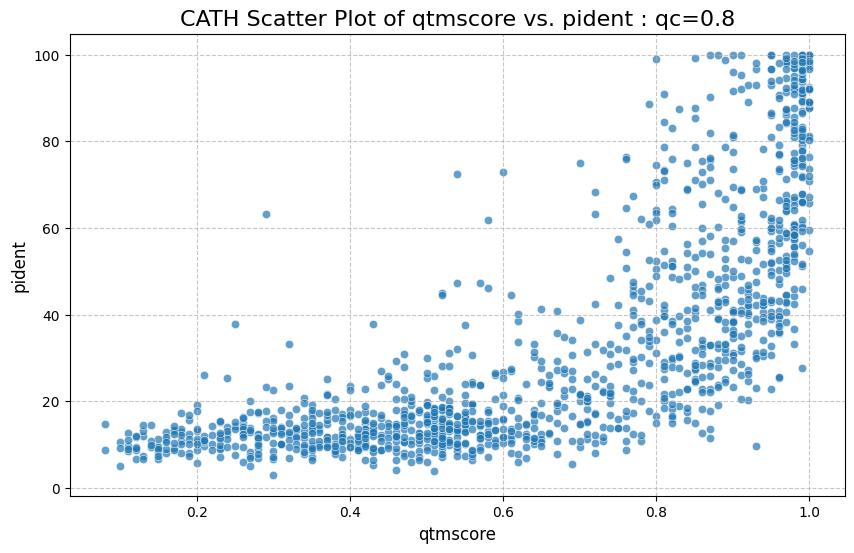

In [10]:
# Let's create a beautiful scatter plot of qtmscore vs. pident
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='qtmscore', y='pident', alpha=0.7)
plt.title('CATH Scatter Plot of qtmscore vs. pident : qc=0.8', fontsize=16)
plt.xlabel('qtmscore', fontsize=12)
plt.ylabel('pident', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

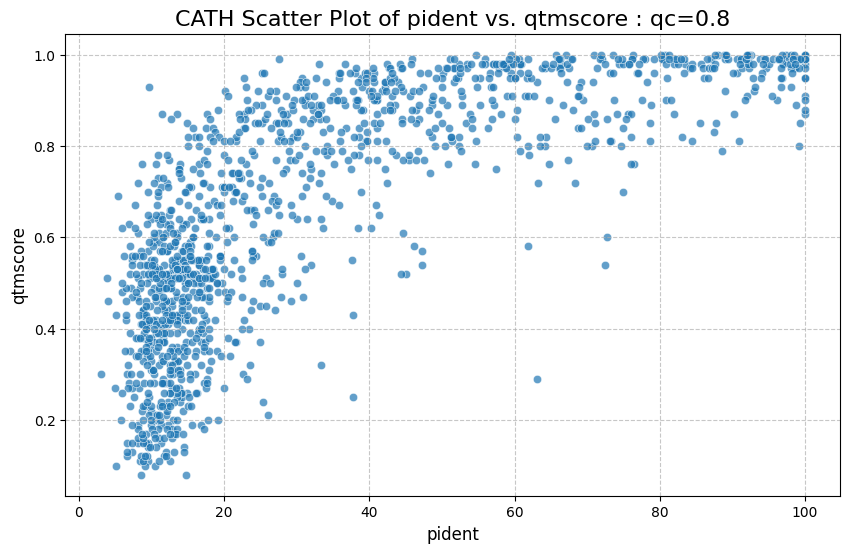

In [11]:
# Let's create a beautiful scatter plot of qtmscore vs. pident
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pident', y='qtmscore', alpha=0.7)
plt.title('CATH Scatter Plot of pident vs. qtmscore : qc=0.8', fontsize=16)
plt.xlabel('pident', fontsize=12)
plt.ylabel('qtmscore', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [12]:
# Calculate correlation between qtmscore and pident
correlation = df[['qtmscore', 'pident']].corr().iloc[0, 1]
print(f"Correlation between qtmscore and pident: {correlation:.4f}")

# Display basic statistics for these columns
print(df[['qtmscore', 'pident']].describe())

Correlation between qtmscore and pident: 0.7469
          qtmscore       pident
count  1274.000000  1274.000000
mean      0.657763    33.892543
std       0.260492    26.942582
min       0.080000     3.000000
25%       0.460000    12.700000
50%       0.690000    22.100000
75%       0.900000    50.150000
max       1.000000   100.000000


In [13]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1274 entries, 0 to 1273
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   cath_query  1274 non-null   object 
 1   dpc_mcid    1274 non-null   object 
 2   dpc_target  1274 non-null   object 
 3   q_range     1274 non-null   object 
 4   t_range     1274 non-null   object 
 5   qlen        1274 non-null   int64  
 6   tlen        1274 non-null   int64  
 7   qcov        1274 non-null   float64
 8   tcov        1274 non-null   float64
 9   alnlen      1274 non-null   int64  
 10  qtmscore    1274 non-null   float64
 11  ttmscore    1274 non-null   float64
 12  alntmscore  1274 non-null   float64
 13  lddt        1158 non-null   float64
 14  pident      1274 non-null   float64
dtypes: float64(7), int64(3), object(5)
memory usage: 149.4+ KB


In [14]:
# Hom many unique queries are there?
unique_queries = df["cath_query"].nunique()
print(f"Number of unique queries: {unique_queries}")
# How many unique MCIDs are there?
unique_mcids = df["dpc_mcid"].nunique()
print(f"Number of unique MCIDs: {unique_mcids}")
# Hom many unique targets are there?
unique_targets = df["dpc_target"].nunique()
print(f"Number of unique targets: {unique_targets}")

Number of unique queries: 1274
Number of unique MCIDs: 965
Number of unique targets: 1262


In [15]:
# Frequency of each MCID
mcid_counts = df["dpc_mcid"].value_counts()
# Top 10 most common MCIDs
top_10_mcids = mcid_counts.head(10)
print("Top 10 most common MCIDs:")
print(top_10_mcids)

Top 10 most common MCIDs:
dpc_mcid
MC8570    24
MC8518    10
MC8385     9
MC8929     8
MC4452     8
MC6931     8
MC7604     7
MC7445     7
MC6557     6
MC7162     6
Name: count, dtype: int64


In [16]:
# We save the cleaned dataset as a csv file
output_path = "/u/mdmc/enyanduk/internship_areasciencepark/Dataframes/DPCStruct/cleaned_annotated_cath_qc0.8_t0.5_l0.5.csv"
df.to_csv(output_path, index=False)